<a href="https://colab.research.google.com/github/shand07/DS160_Final_Project_SPH/blob/main/Food_Delivery_Time_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports**

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.patches as mpatches

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder


**Placing Data inside Data Frame**

In [50]:
df = pd.read_csv('/content/drive/MyDrive/Final Project EDA/Cleaned_Food_Delivery_Data.csv')
df.head()


,Unnamed: 0,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [51]:
#One-Hot Encoder
categorical_cols = ['Weather', 'Vehicle_Type', 'Traffic_Level','Time_of_Day']
onehot_encoder = OneHotEncoder(handle_unknown='ignore')

onehot_encoder.fit(df[categorical_cols])

encoded_col_names = onehot_encoder.get_feature_names_out(categorical_cols)


encoded_array = onehot_encoder.transform(df[categorical_cols]).toarray()
encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names)


print("🧾 One-Hot Encoded Weather & Vehicle_Type Columns:")
display(encoded_df.head())


🧾 One-Hot Encoded Weather & Vehicle_Type Columns:


,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [52]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

**Data Cleaning**

In [53]:


#Data Cleaning
df = df.dropna()

#Exploratory Data Analysis (EDA)
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
print(df.info())
print(df.describe(include='all'))




Shape of dataset: (883, 9)
Columns: ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 883 entries, 0 to 882
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                883 non-null    int64  
 1   Distance_km             883 non-null    float64
 2   Weather                 883 non-null    object 
 3   Traffic_Level           883 non-null    object 
 4   Time_of_Day             883 non-null    object 
 5   Vehicle_Type            883 non-null    object 
 6   Preparation_Time_min    883 non-null    int64  
 7   Courier_Experience_yrs  883 non-null    float64
 8   Delivery_Time_min       883 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 62.2+ KB
None
           Order_ID  Distance_km Weather Traffic_Le

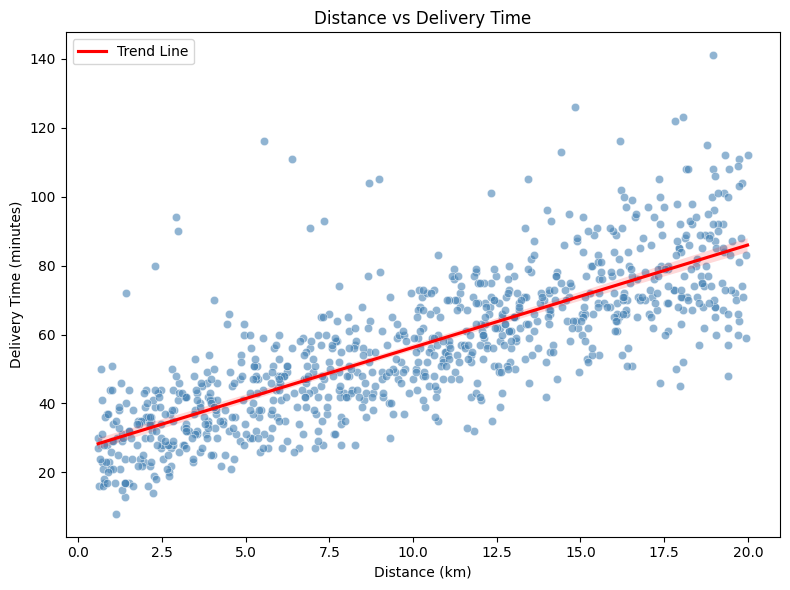

In [54]:
#Scatter plot: Distance vs Delivery Time with a trend line
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min', color='steelblue', alpha=0.6)
sns.regplot(data=df, x='Distance_km', y='Delivery_Time_min', scatter=False, color='red', label='Trend Line')

plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.title('Distance vs Delivery Time')
plt.legend()
plt.tight_layout()
plt.show()


**Graphs**

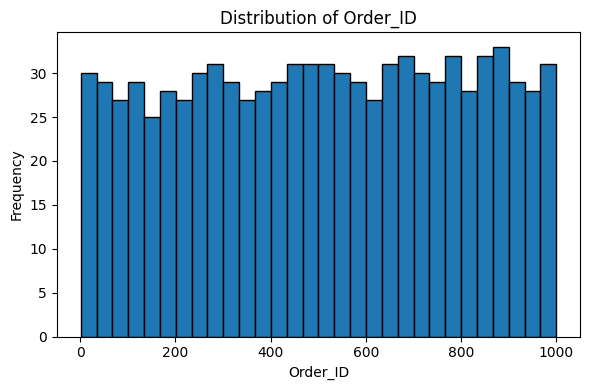

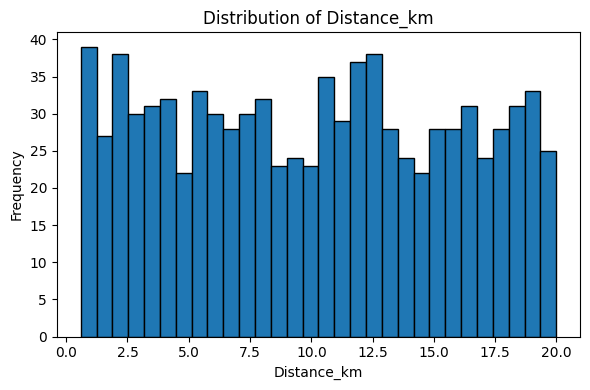

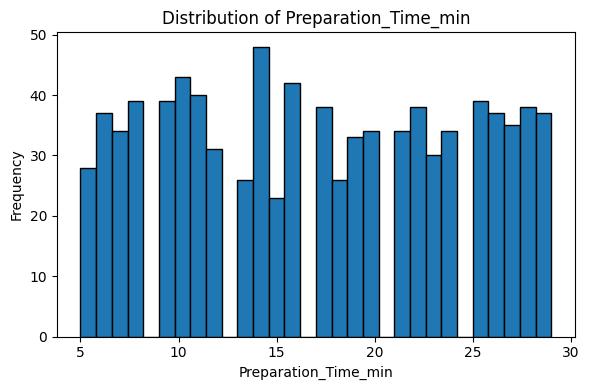

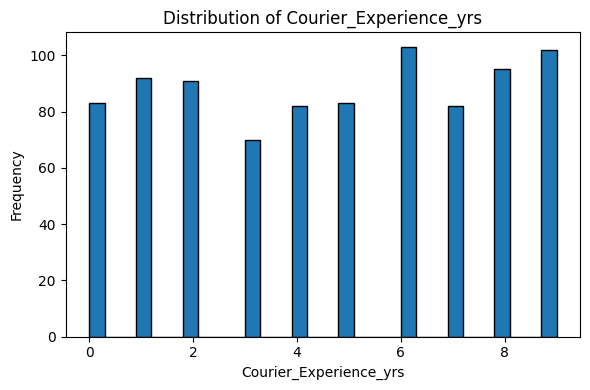

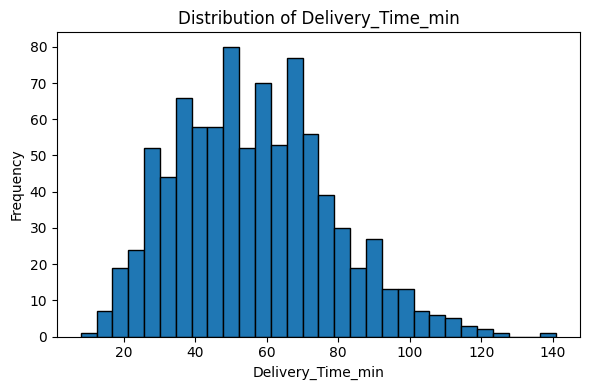

In [55]:
#Histograms for numeric features
numerical_df = df.select_dtypes(include=['float64', 'int64'])
for col in numerical_df.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, edgecolor='k')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [56]:
average_delivery_time = df['Delivery_Time_min'].mean()
print(f"📦 Average Delivery Time: {average_delivery_time:.2f} minutes")

📦 Average Delivery Time: 56.43 minutes


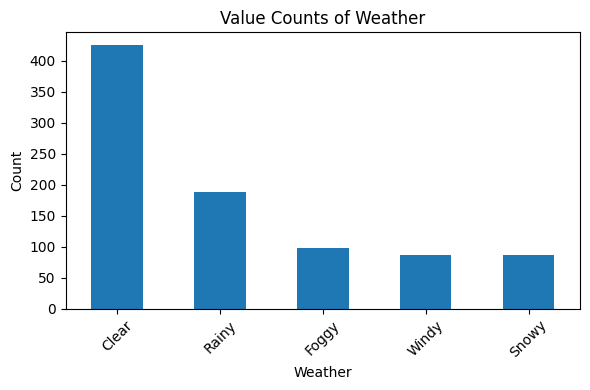

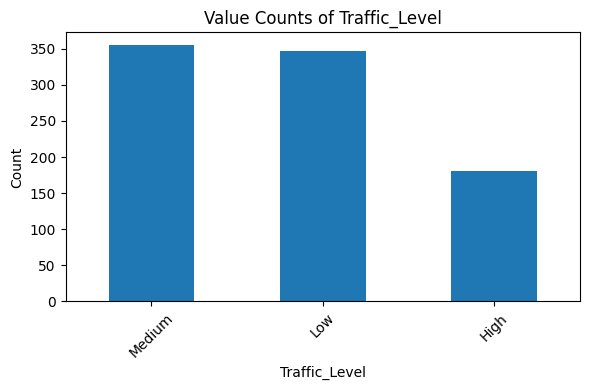

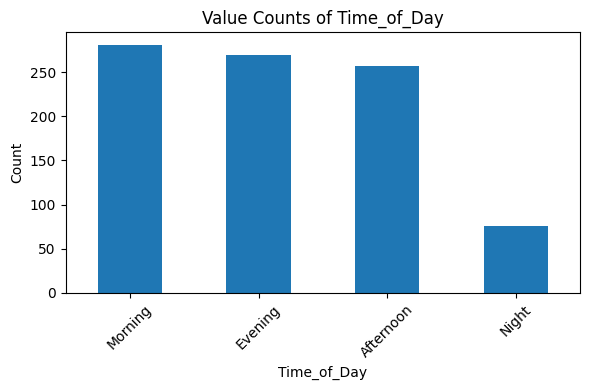

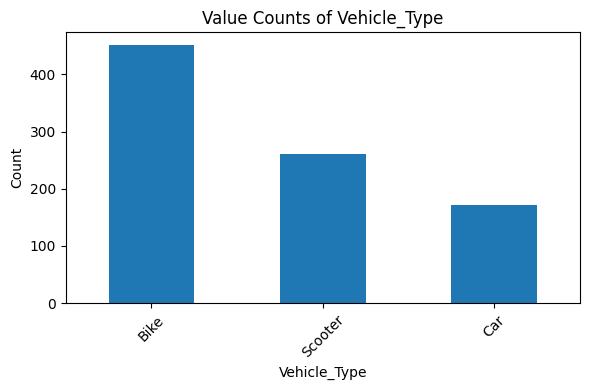

In [57]:
#Bar plots for categorical features
categorical_df = df.select_dtypes(include=['object'])
for col in categorical_df.columns:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Value Counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

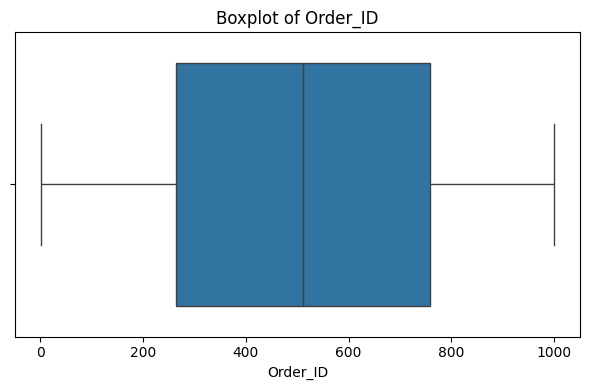

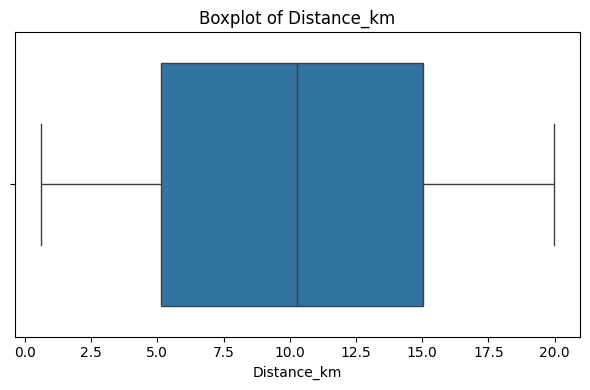

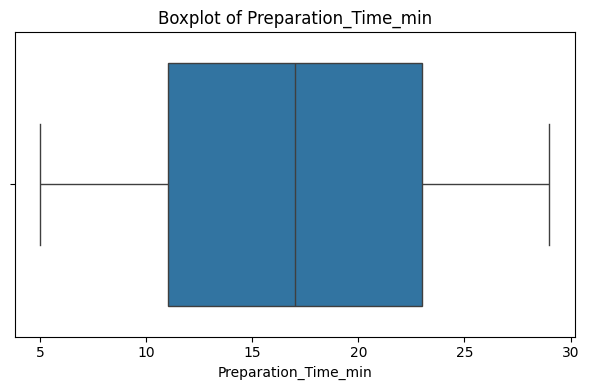

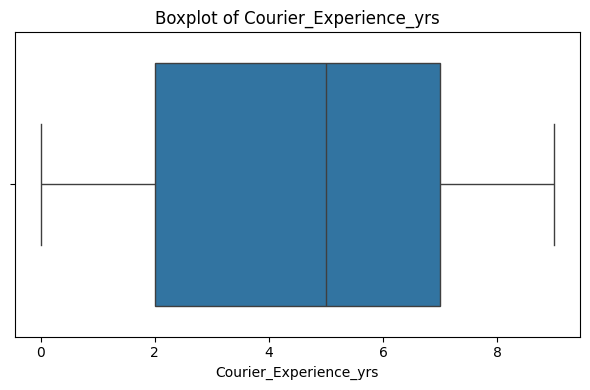

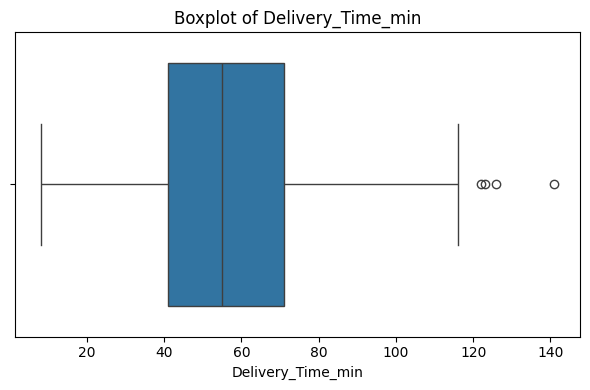

In [58]:
#Boxplots
for col in numerical_df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

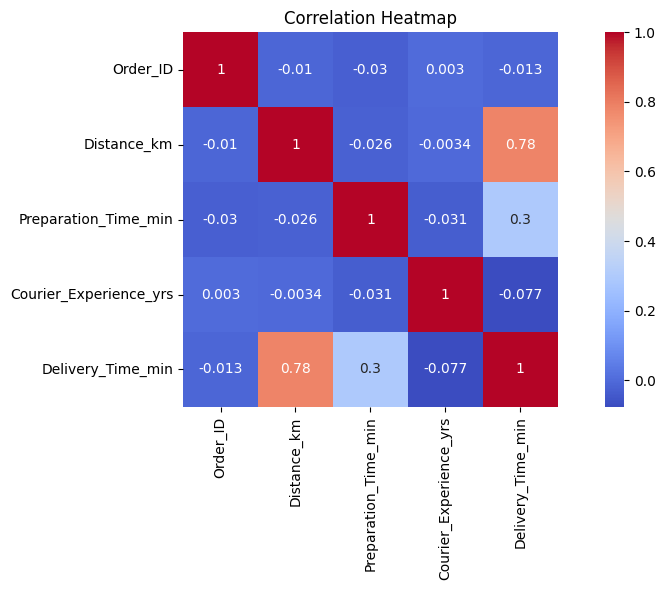

In [59]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**ML Models**

In [81]:
df['Late'] = (df['Delivery_Time_min'] > 56.43).astype(int)

**Linear Regression**

In [82]:
model_features = categorical_cols + ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
X_full = df[model_features]
y_full = df['Delivery_Time_min']

#Drop NA rows
X_full = X_full.dropna()
y_full = y_full.loc[X_full.index]

#Preprocessor for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough'
)

#Linear regression pipeline
linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

#Fit model and predict
linear_pipeline.fit(X_train, y_train)
y_pred = linear_pipeline.predict(X_test)

#Evaluate performance
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))



Linear Regression R²: 0.8325314582304297
Linear Regression MSE: 68.44776976091617


In [83]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} minutes")

RMSE: 8.27 minutes


**Linear Visualizations**

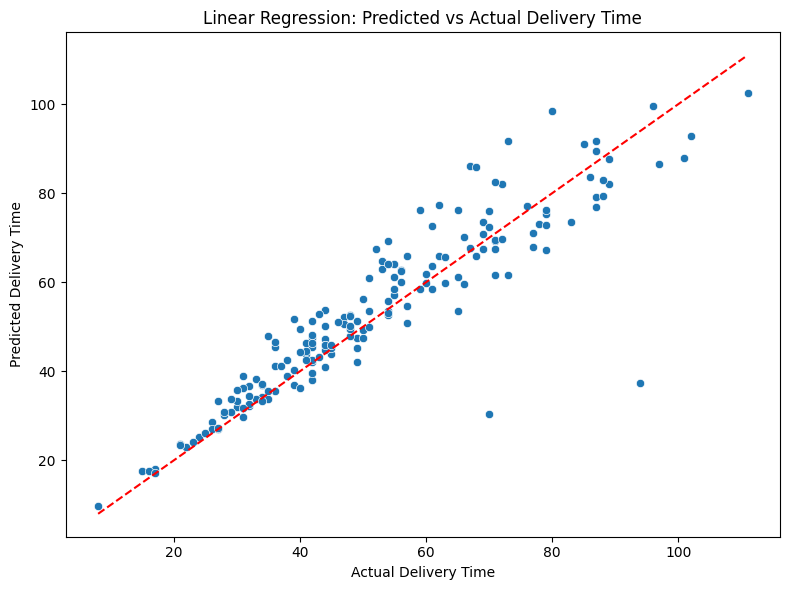

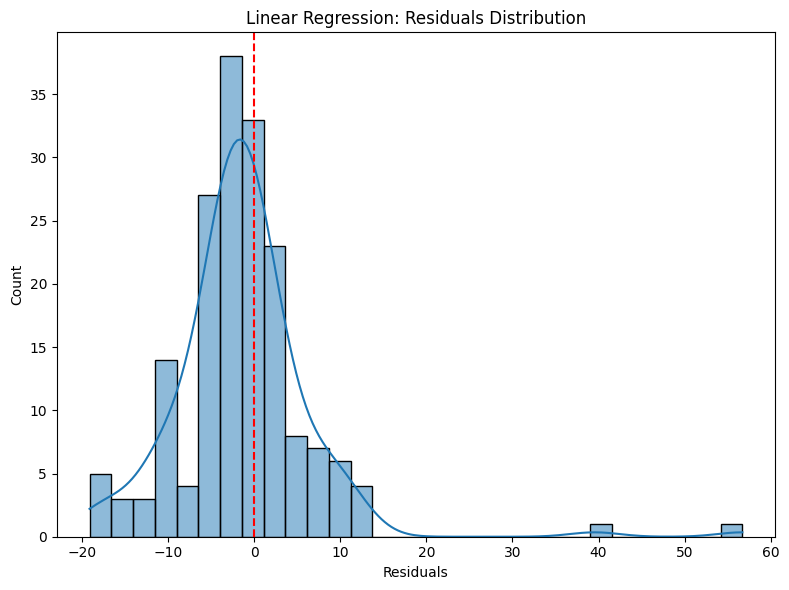

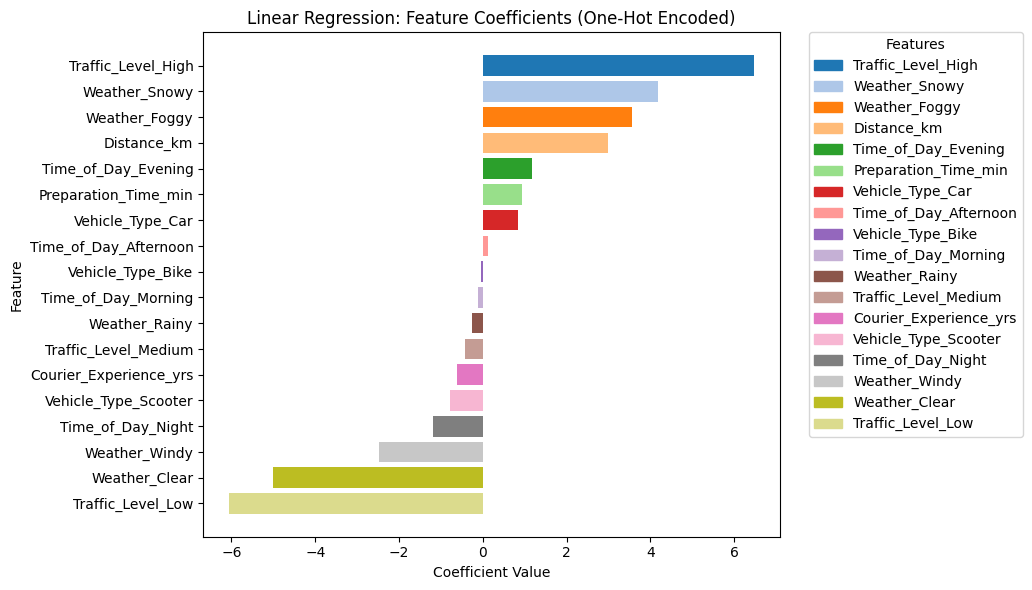

In [84]:
#Predicted vs Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Linear Regression: Predicted vs Actual Delivery Time')
plt.tight_layout()
plt.show()

#Residuals Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.title('Linear Regression: Residuals Distribution')
plt.tight_layout()
plt.show()

#Get encoded feature names
encoded_features = linear_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
final_feature_names = list(encoded_features) + ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

#Get coefficients
coefficients = linear_pipeline.named_steps['regressor'].coef_

#Create DataFrame
coef_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

#Assign unique color to each feature
palette = sns.color_palette("tab20", len(coef_df))
coef_df['Color'] = palette

#Plot
plt.figure(figsize=(8, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=coef_df['Color'])
plt.title('Linear Regression: Feature Coefficients (One-Hot Encoded)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  #Highest at the top
plt.tight_layout()

#Custom legend
legend_handles = [mpatches.Patch(color=row['Color'], label=row['Feature']) for idx, row in coef_df.iterrows()]
plt.legend(handles=legend_handles, title='Features', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

**Logistic Regression**

In [87]:
X = df.drop(columns=['Order_ID', 'Delivery_Time_min', 'Late'])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
y_logistic = df['Late']
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)
logistic_pipeline.fit(X_train_log, y_train_log)
y_pred_log = logistic_pipeline.predict(X_test_log)

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("Precision:", precision_score(y_test_log, y_pred_log))
print("Recall:", recall_score(y_test_log, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_log, y_pred_log))


Logistic Regression Performance
Accuracy: 0.8983050847457628
Precision: 0.8285714285714286
Recall: 0.90625
Confusion Matrix:
 [[101  12]
 [  6  58]]


**Logistic Visualizations**

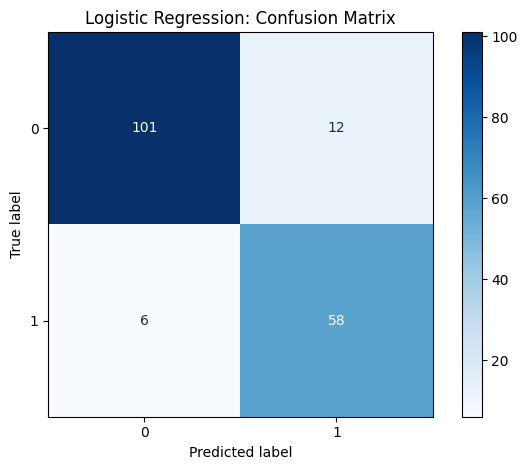

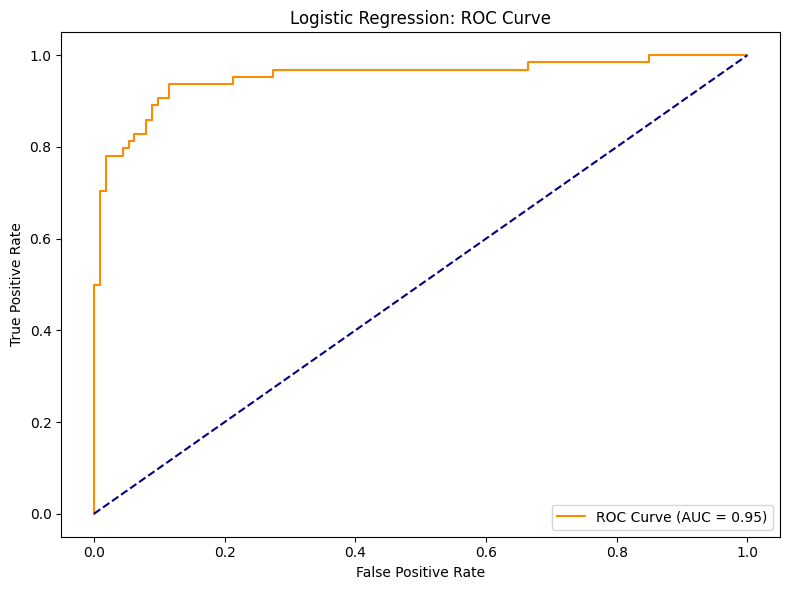

In [86]:
#Confusion Matrix
cm = confusion_matrix(y_test_log, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_pipeline.classes_)
disp.plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.tight_layout()
plt.show()

#ROC Curve
y_pred_log_proba = logistic_pipeline.predict_proba(X_test_log)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_log_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [101]:
#Random Features Sample

encoded_columns = [
    'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
    'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter',
    'Traffic_Level_High', 'Traffic_Level_Low', 'Traffic_Level_Medium',
    'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night'
]


numeric_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

categorical_cols = ['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']
df_encoded = pd.get_dummies(df[categorical_cols], columns=categorical_cols)
df_full = pd.concat([df_encoded, df[numeric_features + ['Delivery_Time_min']]], axis=1).dropna()

random.seed(42)
experiments = []
for i in range(4):
    selected_encoded = random.sample(encoded_columns, 5)
    features_used = selected_encoded + numeric_features
    split = 0.2 if i % 2 == 0 else 0.3
    experiments.append({
        "label": f"Random Set {i+1} ({len(features_used)} features)",
        "features": features_used,
        "split": split
    })

results = []

for exp in experiments:
    X = df_full[exp["features"]]
    y = df_full['Delivery_Time_min']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=exp["split"], random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Experiment": exp["label"],
        "Features Used": ", ".join(exp["features"]),
        "Train Size": f"{int((1 - exp['split']) * 100)}%",
        "Test Size": f"{int(exp['split'] * 100)}%",
        "R²": round(r2, 3),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2)
    })


results_df = pd.DataFrame(results)
display(results_df)

,Experiment,Features Used,Train Size,Test Size,R²,MSE,RMSE
0,Random Set 1 (8 features),"Traffic_Level_Medium, Weather_Foggy, Weather_C...",80%,20%,0.787,87.06,9.33
1,Random Set 2 (8 features),"Weather_Snowy, Time_of_Day_Night, Weather_Rain...",70%,30%,0.794,87.20,9.34
2,Random Set 3 (8 features),"Traffic_Level_Medium, Time_of_Day_Afternoon, T...",80%,20%,0.802,80.97,9.00
3,Random Set 4 (8 features),"Vehicle_Type_Car, Weather_Clear, Time_of_Day_M...",70%,30%,0.792,87.95,9.38
